# Load Raw BBC Dataset

In [ ]:
from pathlib import Path
import pandas as pd

data_dir = Path("/content/drive/MyDrive/bbc")

rows = []

for label_dir in data_dir.iterdir():
    if label_dir.is_dir():
        label = label_dir.name

        for file_path in label_dir.glob("*.txt"):
            text = file_path.read_text(encoding="latin-1")
            rows.append({
                "text": text,
                "label": label
            })

df = pd.DataFrame(rows)

print(df.head())
print(df["label"].value_counts())

                                                text  label
0  Collins to compete in Birmingham\n\nWorld and ...  sport
1  Chepkemei hit by big ban\n\nKenya's athletics ...  sport
2  Greek pair attend drugs hearing\n\nGreek sprin...  sport
3  Holmes secures comeback victory\n\nBritain's K...  sport
4  UK Athletics agrees new kit deal\n\nUK Athleti...  sport
label
sport            511
business         510
politics         417
tech             401
entertainment    386
Name: count, dtype: int64


# Clean text Data

In [ ]:
df = df.dropna(subset=["text", "label"])

df["text"] = df["text"].astype(str).str.strip()
df = df[df["text"].str.len() > 0]

print(df.shape)

(2225, 2)


# Encode Label

In [ ]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

df["label_id"] = label_encoder.fit_transform(df["label"])

print(label_encoder.classes_)
print(df[["label", "label_id"]].head())

['business' 'entertainment' 'politics' 'sport' 'tech']
   label  label_id
0  sport         3
1  sport         3
2  sport         3
3  sport         3
4  sport         3


# Train/Validation/Test Split

In [ ]:
from sklearn.model_selection import train_test_split

train_df, temp_df = train_test_split(
    df,
    test_size=0.2,
    random_state=42,
    stratify=df["label_id"]
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.5,
    random_state=42,
    stratify=temp_df["label_id"]
)

print(len(train_df), len(val_df), len(test_df))

1780 222 223


# Initialize BertTokenizer

In [ ]:
from transformers import BertTokenizer

tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

# Testing on 1 text

In [ ]:
sample_text = train_df.iloc[0]["text"]

encoding = tokenizer(
    sample_text,
    padding="max_length",
    truncation=True,
    max_length=256,
    return_tensors="pt"
)

print(encoding.keys())
print(encoding["input_ids"].shape)
print(encoding["attention_mask"].shape)
print(encoding["token_type_ids"].shape)

KeysView({'input_ids': tensor([[  101,  6547, 20626,  2047,  9805, 15710,  3954,  1996,  6580,  1997,
          3607,  1005,  1055,  9805,  5289,  6711,  2638,  6199, 29107,  2015,
          1011,  1996,  3514,  3813,  2853,  2000,  1037,  2210,  1011,  2124,
         17634,  2006,  4465,  1011,  2003,  1996,  3395,  1997, 15762, 12143,
          1999,  4924,  1012, 21790, 12902,  5446,  2177,  6003,  2004,  1996,
         10470,  3453,  1010, 16191,  2000,  3477, 13539,  1012,  4293, 24700,
         20996, 12083,  4244,  1006,  1037, 29646,  2549,  1012,  1022, 24700,
          1025,  1002,  1023,  1012,  1018, 24700,  1007,  1012,  3607,  1005,
          1055,  6399,  3555,  2008, 21790, 12902,  2001,  1037,  2392,  2005,
          3806, 15404, 11721,  2480, 21572,  2213,  1010,  2029,  2018,  2042,
          3517,  2000,  2663,  1012,  1996,  5096,  2038,  3908,  9805, 15710,
          1010,  2320,  1996,  3954,  1997,  9805,  5289,  6711,  2638,  6199,
         29107,  2015,  1010,

In [ ]:
input_ids = encoding["input_ids"]
attention_mask = encoding["attention_mask"]
token_type_ids = encoding["token_type_ids"]

# Building Pytorch Dataset

In [ ]:
import torch
from torch.utils.data import Dataset

class BBCDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_length=256):
        self.texts = texts.tolist()
        self.labels = labels.tolist()
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = self.texts[idx]
        label = self.labels[idx]

        encoding = self.tokenizer(
            text,
            padding="max_length",
            truncation=True,
            max_length=self.max_length,
            return_tensors="pt"
        )

        return {
            "input_ids": encoding["input_ids"].squeeze(0),
            "attention_mask": encoding["attention_mask"].squeeze(0),
            "token_type_ids": encoding["token_type_ids"].squeeze(0),
            "labels": torch.tensor(label, dtype=torch.long)
        }

# Split Train/Val/Test Dataset

In [ ]:
train_dataset = BBCDataset(
    train_df["text"],
    train_df["label_id"],
    tokenizer,
    max_length=256
)

val_dataset = BBCDataset(
    val_df["text"],
    val_df["label_id"],
    tokenizer,
    max_length=256
)

test_dataset = BBCDataset(
    test_df["text"],
    test_df["label_id"],
    tokenizer,
    max_length=256
)

# Buidl DataLoader

In [ ]:
from torch.utils.data import DataLoader

train_loader = DataLoader(
    train_dataset,
    batch_size=16,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=16,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=16,
    shuffle=False
)

# Veify Batch Output

In [ ]:
batch = next(iter(train_loader))

print("input_ids:", batch["input_ids"].shape)
print("attention_mask:", batch["attention_mask"].shape)
print("token_type_ids:", batch["token_type_ids"].shape)
print("labels:", batch["labels"].shape)

input_ids: torch.Size([16, 256])
attention_mask: torch.Size([16, 256])
token_type_ids: torch.Size([16, 256])
labels: torch.Size([16])


MODEL

In [ ]:
import torch
from transformers import BertForSequenceClassification
from torch.optim import AdamW
from transformers import get_linear_schedule_with_warmup

device = torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu")
print(f"Mô hình sẽ được huấn luyện trên: {device}")


model = BertForSequenceClassification.from_pretrained(
    "bert-base-uncased",
    num_labels=5
)
model.to(device)

# 3. Cấu hình các Siêu tham số (Hyperparameters)
epochs = 3
# Learning rate siêu nhỏ (2e-5) để tránh phá vỡ kiến thức cũ của BERT
optimizer = AdamW(model.parameters(), lr=2e-5, eps=1e-8)

# 4. Thiết lập Scheduler để giảm dần tốc độ học theo thời gian
total_steps = len(train_loader) * epochs
scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=0,  # Đi thẳng vào learning rate lớn nhất rồi giảm dần
    num_training_steps=total_steps
)

print(f"Tổng số bước huấn luyện (steps): {total_steps}")

Mô hình sẽ được huấn luyện trên: cuda


config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Tổng số bước huấn luyện (steps): 336


In [ ]:

import numpy as np


def train_epoch(model, data_loader, optimizer, scheduler, device):

    model.train()
    total_train_loss = 0


    for batch in data_loader:


        optimizer.zero_grad()

        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)


        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            labels=labels
        )

        loss = outputs.loss
        total_train_loss += loss.item()


        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        # 6. ADAMW VÀ SCHEDULER RA TAY:
        optimizer.step()
        scheduler.step()

    # Trả về sai số trung bình của toàn bộ các mẻ dữ liệu trong vòng này
    return total_train_loss / len(data_loader)



def eval_model(model, data_loader, device):

    model.eval()
    total_eval_loss = 0
    correct_predictions = 0

    with torch.no_grad():
        for batch in data_loader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)


            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask,
                labels=labels
            )

            loss = outputs.loss
            total_eval_loss += loss.item()


            logits = outputs.logits

            preds = torch.argmax(logits, dim=1)


            correct_predictions += torch.sum(preds == labels)

    # Tính toán các chỉ số đầu ra
    avg_loss = total_eval_loss / len(data_loader)
    accuracy = correct_predictions.item() / len(data_loader.dataset)

    return avg_loss, accuracy

In [ ]:
import time

print(" Kích hoạt vòng lặp chính! Bắt đầu huấn luyện tinh chỉnh BERT...")

# Định cấu hình số vòng lặp (Epochs)
epochs = 3

for epoch in range(epochs):
    # Ghi lại thời gian bắt đầu của Epoch này
    start_time = time.time()
    print(f"\n--- Epoch {epoch + 1} / {epochs} ---")

    # BƯỚC 1: Gửi tập TRAIN vào cho mô hình học và cập nhật trọng số
    train_loss = train_epoch(model, train_loader, optimizer, scheduler, device)
    print(f"Train Loss (Sai số tập học): {train_loss:.4f}")

    # BƯỚC 2: Gửi tập VAL vào để kiểm tra năng lực hiện tại của mô hình
    val_loss, val_acc = eval_model(model, val_loader, device)
    print(f"Validation Loss (Sai số tập thi): {val_loss:.4f}")
    print(f"Validation Accuracy (Độ chính xác thử nghiệm): {val_acc * 100:.2f}%")

    # Tính tổng thời gian đã chạy của Epoch này
    elapsed_time = time.time() - start_time
    print(f"Thời gian hoàn thành Epoch: {elapsed_time:.2f} giây")

print("\n Quá trình huấn luyện 3 Epoch hoàn tất!")

🚀 Kích hoạt vòng lặp chính! Bắt đầu huấn luyện tinh chỉnh BERT...

--- Epoch 1 / 3 ---
Train Loss (Sai số tập học): 0.5366
Validation Loss (Sai số tập thi): 0.0578
Validation Accuracy (Độ chính xác thử nghiệm): 99.55%
Thời gian hoàn thành Epoch: 77.81 giây

--- Epoch 2 / 3 ---
Train Loss (Sai số tập học): 0.0668
Validation Loss (Sai số tập thi): 0.0207
Validation Accuracy (Độ chính xác thử nghiệm): 99.55%
Thời gian hoàn thành Epoch: 86.49 giây

--- Epoch 3 / 3 ---
Train Loss (Sai số tập học): 0.0289
Validation Loss (Sai số tập thi): 0.0110
Validation Accuracy (Độ chính xác thử nghiệm): 100.00%
Thời gian hoàn thành Epoch: 88.02 giây

✅ Quá trình huấn luyện 3 Epoch hoàn tất!


/tmp/ipykernel_3096/1230938510.py:27: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "g-^" (-> color='g'). The keyword argument will take precedence.
  ax2.plot(epochs_range, val_accuracies, 'g-^', label='Validation Accuracy', linewidth=2, color='darkgreen')


📊 Đã vẽ xong! Đồ thị báo cáo đã được lưu thành file: 'bert_training_report.png'


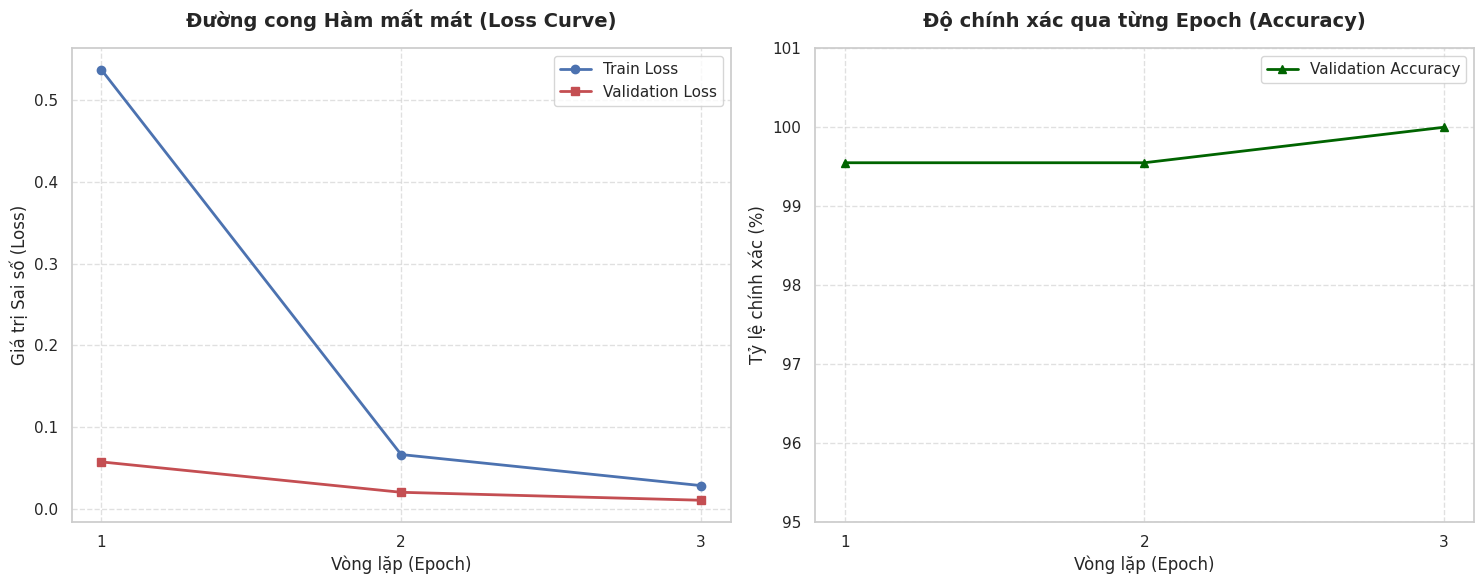

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Thiết lập phông nền chuẩn mực cho đồ thị báo cáo
sns.set_theme(style="whitegrid")

# 1. Tự tay nạp dữ liệu lịch sử từ kết quả bạn vừa chạy được
epochs_range = [1, 2, 3]
train_losses = [0.5366, 0.0668, 0.0289]
val_losses = [0.0578, 0.0207, 0.0110]
val_accuracies = [99.55, 99.55, 100.00]

# 2. Khởi tạo một khung tranh gồm 2 đồ thị nằm cạnh nhau
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# --- ĐỒ THỊ 1: ĐƯỜNG CONG MẤT MÁT (LOSS CURVE) ---
ax1.plot(epochs_range, train_losses, 'b-o', label='Train Loss', linewidth=2)
ax1.plot(epochs_range, val_losses, 'r-s', label='Validation Loss', linewidth=2)
ax1.set_title('Đường cong Hàm mất mát (Loss Curve)', fontsize=14, fontweight='bold', pad=15)
ax1.set_xlabel('Vòng lặp (Epoch)', fontsize=12)
ax1.set_ylabel('Giá trị Sai số (Loss)', fontsize=12)
ax1.set_xticks(epochs_range)
ax1.legend(fontsize=11)
ax1.grid(True, linestyle='--', alpha=0.6)

# --- ĐỒ THỊ 2: ĐỘ CHÍNH XÁC (ACCURACY CURVE) ---
ax2.plot(epochs_range, val_accuracies, 'g-^', label='Validation Accuracy', linewidth=2, color='darkgreen')
ax2.set_title('Độ chính xác qua từng Epoch (Accuracy)', fontsize=14, fontweight='bold', pad=15)
ax2.set_xlabel('Vòng lặp (Epoch)', fontsize=12)
ax2.set_ylabel('Tỷ lệ chính xác (%)', fontsize=12)
ax2.set_xticks(epochs_range)
ax2.set_ylim(95, 101) # Giới hạn cận để nhìn rõ độ tăng trưởng ở mức cao
ax2.legend(fontsize=11)
ax2.grid(True, linestyle='--', alpha=0.6)

# Tự động căn chỉnh để các chữ không bị đè lên nhau
plt.tight_layout()

# Lưu đồ thị thành file ảnh chất lượng cao để chèn vào báo cáo Word/PowerPoint
output_image_path = "bert_training_report.png"
plt.savefig(output_image_path, dpi=300, bbox_inches='tight')
print(f" Đã vẽ xong! Đồ thị báo cáo đã được lưu thành file: '{output_image_path}'")

🔮 Đã vẽ xong Ma trận nhầm lẫn! Ảnh đã được lưu tại: 'bert_confusion_matrix.png'


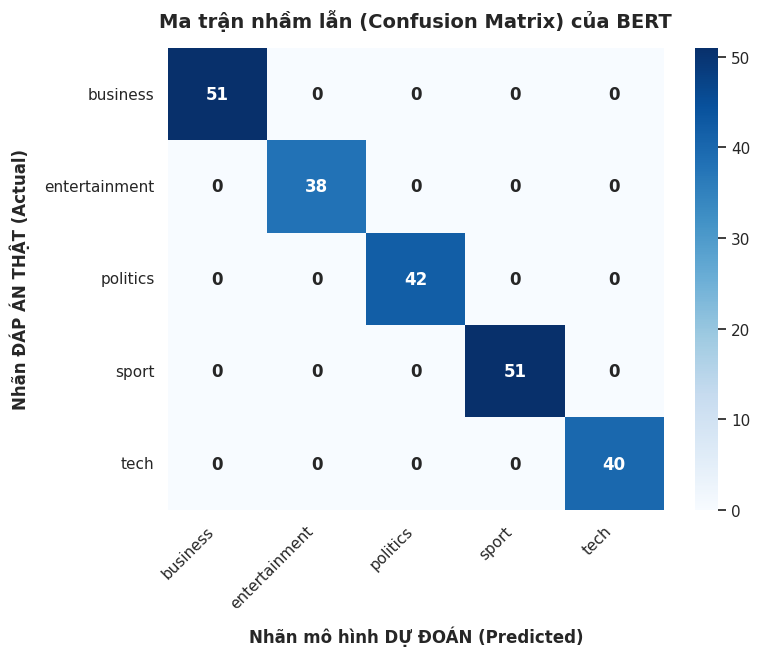

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Tiến hành thu thập dự đoán thực tế từ mô hình
model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for batch in val_loader:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        preds = torch.argmax(outputs.logits, dim=1)

        # Đẩy kết quả về CPU và chuyển sang dạng mảng numpy để sklearn xử lý
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# 2. Tính toán ma trận nhầm lẫn dựa trên các nhãn chữ gốc của BBC
cm = confusion_matrix(all_labels, all_preds)
class_names = label_encoder.classes_  # Lấy danh sách 5 tên chuyên mục gốc

# 3. Vẽ biểu đồ nhiệt (Heatmap)
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,          # Hiện số lượng bài báo cụ thể vào từng ô
    fmt='d',             # Định dạng số nguyên
    cmap='Blues',        # Tông màu xanh chuyên nghiệp
    xticklabels=class_names,
    yticklabels=class_names,
    annot_kws={"size": 12, "weight": "bold"}
)

# Đặt tiêu đề cho đồ thị (Hàm này dùng tham số `pad` hoàn toàn hợp lệ)
ax.set_title('Ma trận nhầm lẫn (Confusion Matrix) của BERT', fontsize=14, fontweight='bold', pad=15)

# ĐÃ SỬA TẠI ĐÂY: Thay `pad=10` bằng `labelpad=10` để tránh lỗi hệ thống
ax.set_xlabel('Nhãn mô hình DỰ ĐOÁN (Predicted)', fontsize=12, fontweight='bold', labelpad=10)
ax.set_ylabel('Nhãn ĐÁP ÁN THẬT (Actual)', fontsize=12, fontweight='bold', labelpad=10)

plt.xticks(rotation=45, ha='right') # Xoay chữ 45 độ để không bị đè nhau
plt.yticks(rotation=0)

# Lưu ma trận thành file ảnh
cm_image_path = "bert_confusion_matrix.png"
plt.savefig(cm_image_path, dpi=300, bbox_inches='tight')
print(f" Đã vẽ xong Ma trận nhầm lẫn! Ảnh đã được lưu tại: '{cm_image_path}'")